# Project Overview

This project aims to create a Convolution Neural Network that classifies the CIFAR Dataset. The CIFAR-10 dataset is a widely used collection of 60,000
pixel color images in 10 classes, commonly used for training machine learning and computer vision algorithms. Developed by researchers at the University of Toronto, it features 50,000 training images and 10,000 test images (6,000 per class) covering objects like airplanes, cars, cats, and dogs.

In [4]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [3]:
#Import resources
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Loading and splitting dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
'''
the training dataset is composed of 50000 images
32 pixel width
32 pixel height
composed of 3 colour channels
color channels are grayscale representation of pixels in the three primary colors (red, green, blue)
'''

train_images.shape

(50000, 32, 32, 3)

In [9]:
'''
representation of a single pixel
composed of 3 intensity values
each value represents its intensity in a specific color channel
'''

train_images[0][23][23]

array([91, 60, 34], dtype=uint8)

In [10]:
# Normalizing pixel values
# This is to improve speed perfomance
# Also to prevent bias in assigning weights
train_images,test_images = train_images/255 , test_images/255

In [12]:
# Class Names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(len(class_names))

10


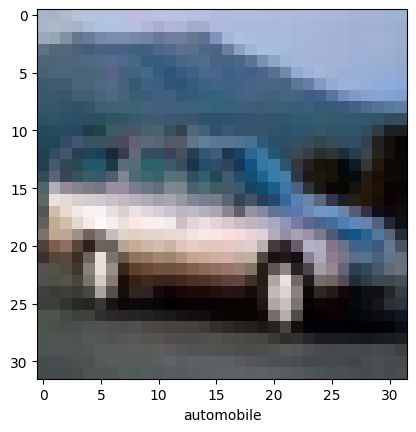

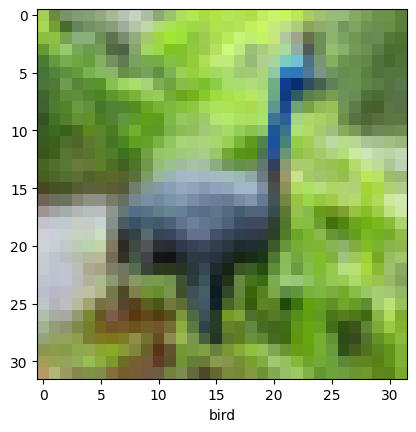

In [19]:
# Visualizing images
IMG_INDEX = 4
plt.imshow(train_images[IMG_INDEX])
plt.xlabel(class_names[train_labels[IMG_INDEX][0]])
plt.show()

plt.figure
IMG_INDEX2= 6
plt.imshow(train_images[IMG_INDEX2])
plt.xlabel(class_names[train_labels[IMG_INDEX2][0]])
plt.show()



In [21]:
#Defining shape
shape = train_images[0].shape
print(shape)

(32, 32, 3)


In [39]:
# Building and Stacking Up Convolution Network
from tensorflow import keras
from keras import layers
model = keras.Sequential()

Conv_layer1=(layers.Conv2D(32,(3,3), activation = 'relu',input_shape = shape))
Maxpool_layer1 = (layers.MaxPooling2D(2,2))
Conv_layer2 = (layers.Conv2D(64,(3,3),activation = 'relu'))
Maxpool_layer2 =(layers.MaxPooling2D(2,2))
Conv_layer3 = (layers.Conv2D(64,(3,3),activation ='relu'))

model.add(Conv_layer1)
model.add(Maxpool_layer1)
model.add(Conv_layer2)
model.add(Maxpool_layer2)
model.add(Conv_layer3)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Data Flow
Data enters the first convolution layer (Conv_layer1), where it is convolved using a (3,3) kernel (or filter). For an input with 3 color channels, each filter will also have a depth of 3. The result for each filter is a single response map (or feature map). With 32 filters, a total of 32 such feature maps are generated.

A feature map shows the presence of particular features detected by a filter across different areas of the image. A high positive output indicates a strong likelihood of that feature being present. Each response value in the feature map has a bias added and is then activated by the ReLU function, which introduces non-linearity.

These feature maps then pass through Maxpool_layer1, which reduces their spatial dimensions (e.g., from 30x30 to 15x15). This downsampling saves computational power and helps prevent overfitting. Because of the ReLU activation, any negative values from the convolution are set to zero. Max pooling selects the highest positive value within a local window, indicating the strongest presence of a feature in that region. This intensity signifies that a particular feature was highly detected in that section.

Max pooling also introduces translational invariance, meaning the model becomes less sensitive to the exact position of features, allowing it to learn more abstract representations rather than memorizing individual pixel locations. This is vital as the model can learn abstract features despite the position of the object in the image.

Then, the pooled feature maps go to the second convolution layer (Conv_layer2). Here, the process repeats: 64 new filters (each with a depth matching the input from the previous pooling layer) are applied to extract more complex features. These results are again activated by ReLU, followed by Maxpool_layer2 for further downsampling and increased abstraction. This sequential application of convolution and pooling layers allows the network to progressively learn more complex and abstract features from the input images.



In [40]:
#models information

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
'''
the 3D output of the convolution final Conv layer
No longer reprsent raw pixel values
But instead high abstract feautures
represented by single numeric values
For instance, one value in the 1024-element vector might indicate the presence of a 'furry texture with a pointed ear shape', another might signal 'round wheel-like object', and yet another 'smooth, metallic surface'.
'''



model.add(layers.Flatten())
model.add(layers.Dense(64,activation = 'relu'))
model.add(layers.Dense(10,activation = 'softmax'))

In [42]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
#compiling model
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

# TRAINING MODEL

In [45]:
training_model = model.fit(train_images,train_labels,epochs = 20, validation_data= (test_images, test_labels))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.3508 - loss: 1.7549 - val_accuracy: 0.5315 - val_loss: 1.2908
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.5617 - loss: 1.2283 - val_accuracy: 0.6112 - val_loss: 1.0942
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6299 - loss: 1.0381 - val_accuracy: 0.6554 - val_loss: 0.9866
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.6761 - loss: 0.9327 - val_accuracy: 0.6640 - val_loss: 0.9528
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.6995 - loss: 0.8587 - val_accuracy: 0.6813 - val_loss: 0.9134
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 48ms/step - accuracy: 0.7214 - loss: 0.7988 - val_accuracy: 0.6938 - val_loss: 0.8780
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.7370 - loss: 0.7499 - val_accuracy: 0.6967 - val_loss: 0.8806
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.7506 

In [46]:
model.evaluate(test_images,test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7088 - loss: 1.0620


[1.0907986164093018, 0.7044000029563904]

In [50]:
models_predictions = model.predict(test_images[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


Clothing 1 is predicted to be cat by the model with a probability of (98.00)%


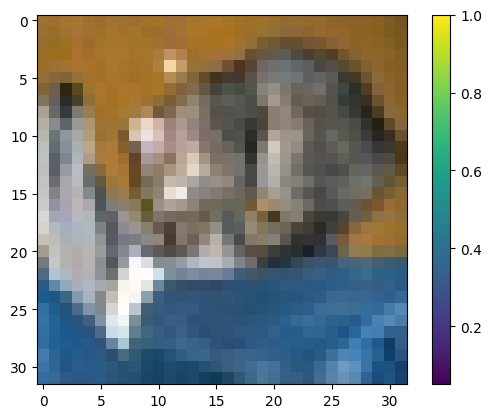

Clothing 2 is predicted to be ship by the model with a probability of (96.05)%


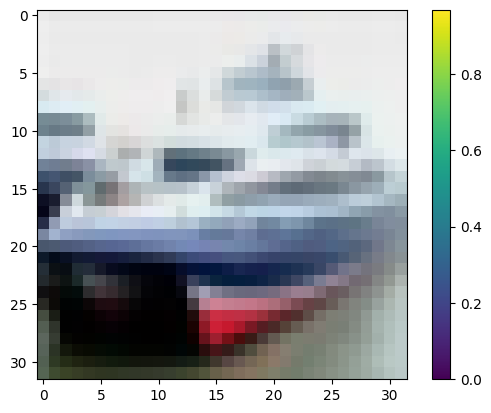

Clothing 3 is predicted to be ship by the model with a probability of (79.00)%


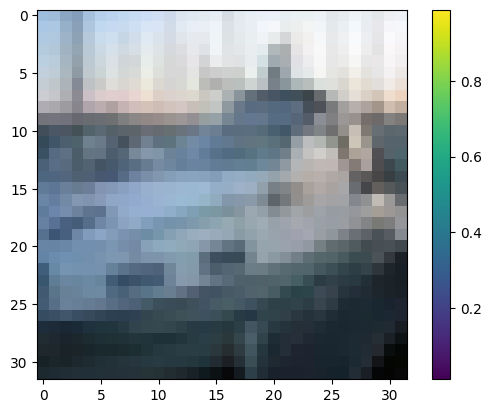

Clothing 4 is predicted to be airplane by the model with a probability of (99.47)%


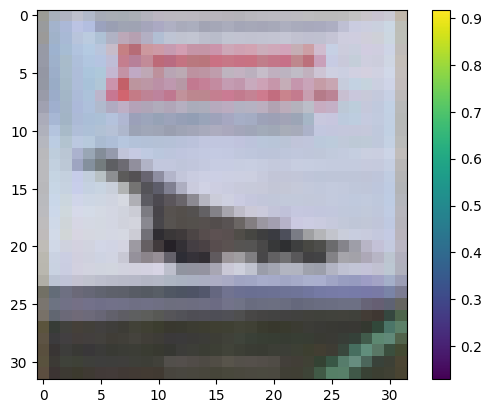

Clothing 5 is predicted to be frog by the model with a probability of (95.38)%


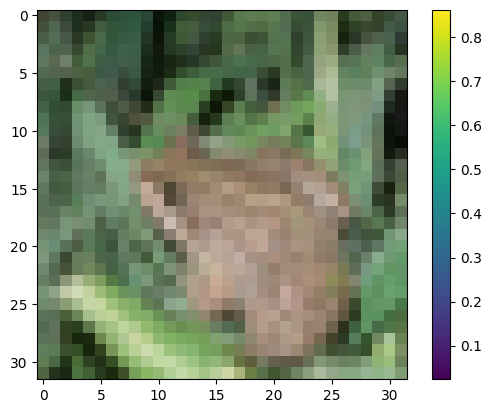

In [51]:
for index,prediction in enumerate(models_predictions,1):
  class_id = np.argmax(prediction)
  probability=prediction[class_id]
  print(f"Clothing {index} is predicted to be {class_names[class_id]} by the model with a probability of ({100*probability:.2f})%")
  plt.figure()
  plt.imshow(test_images[index-1])
  plt.colorbar()
  plt.grid(False)
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


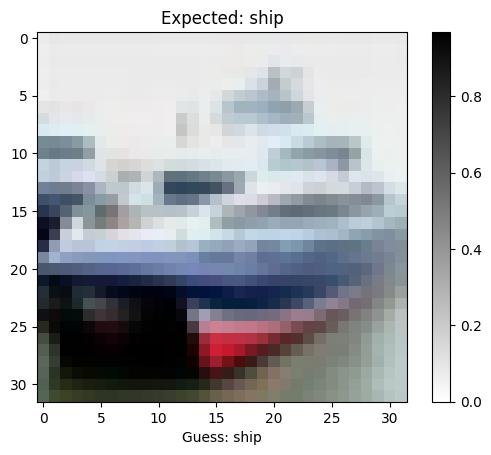

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


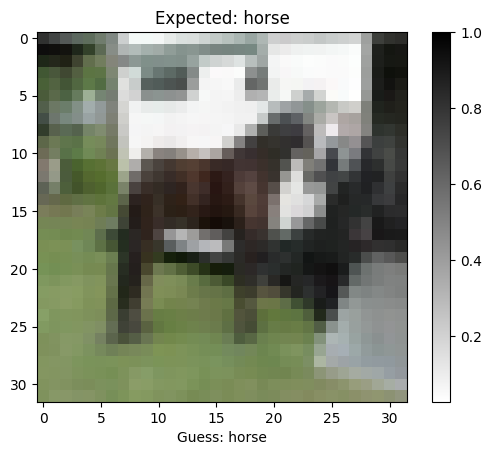

In [60]:
def show_image(img, label, guess):
    plt.figure()
    plt.imshow(img, cmap=plt.cm.binary)
    plt.title("Expected: " + label)
    plt.xlabel("Guess: " + guess)
    plt.colorbar()
    plt.grid(False)
    plt.show()

img = test_images[1]
label = class_names[test_labels[1][0]]
guess = class_names[np.argmax(model.predict(np.expand_dims(test_images[1], axis=0)))]
show_image(img, label, guess)

img2 = test_images[20]
label2= class_names[test_labels[20][0]]
guess2 = class_names[np.argmax(model.predict(np.expand_dims(test_images[20], axis=0)))]
show_image(img2, label2, guess2)


# NOTES
# What the Dense Network Does
The dense layers, also known as fully connected layers, take this flattened vector of high-level features and perform the final classification based on the relationships between these features. They are designed to learn complex, non-linear combinations of these features.

# All Questions I  asked Gemini and solutions given

1.  If the first Convolution block checks vertical lines, what do the second Conv block and third do? (With more examples)
Detailed Answer: This highlights the hierarchical nature of feature learning in CNNs. Features are learned in progressively more complex stages:
First Convolutional Block (Conv_layer1 + Maxpool_layer1): This block operates directly on the raw pixel data. It learns to detect very basic, low-level features. For example, if we're looking at an image of a dog from CIFAR-10:Filters might activate strongly for horizontal edges (like the top of the dog's head or back).
Other filters might find vertical edges (like the side of its leg).
Some filters might specialize in diagonal lines (e.g., the slope of its snout).
Others might detect specific textures (like the fur's grain) or corners.
Second Convolutional Block (Conv_layer2 + Maxpool_layer2): This block doesn't see raw pixels. Instead, its input is the collection of feature maps from the first block – essentially, it sees where those basic edges, textures, and corners were detected. It then learns to combine these simpler features into slightly more complex, mid-level patterns. Continuing with the dog example:It might combine curved edges and textures to recognize a rough 'eye' shape.
It could combine various lines and corners to form the outline of a 'snout'.
It might detect a particular combination of lines and texture that signifies a 'dog ear'.
Perhaps it identifies a 'furry patch' that is denser in certain areas.
Third Convolutional Layer (Conv_layer3): This layer takes the output of the second block (which are already mid-level features). It learns to combine these mid-level features into even more abstract, high-level, and semantically meaningful parts of the object. For the dog:

2. It could combine the 'eye' shape, 'snout' outline, and 'furry patch' to recognize a full 'dog face'.
It might identify the distinct 'body contour' of a dog, integrating multiple 'furry patches' and edge detections.
Ultimately, these abstract features become highly indicative of the object itself.Purpose of passing the output of convolutional layers to a dense network?
Detailed Answer: After the convolutional blocks have extracted these hierarchical features (e.g., from pixels -> edges -> shapes -> dog face/ear/body), their multi-dimensional output (e.g., (batch_size, 4, 4, 64) feature maps) needs to be prepared for the final classification. This is done by a Flatten layer, which reshapes the 3D feature maps into a single, long 1D vector (e.g., (batch_size, 1024)). This vector no longer represents raw pixel values but rather a dense encoding of the abstract, high-level features detected by the CNNThe Dense (fully connected) layers then receive this flattened vector. Their purpose is to learn the intricate, non-linear relationships and combinations among these high-level features to make the final classification decision. For example, the dense layers would learn:

3. "If feature_X (representing 'dog face') is highly active, AND feature_Y (representing 'dog body contour') is also active, then it's very likely a 'dog'."
"But if feature_Z (representing 'wheel') is highly active, it's more likely a 'car'." The final dense layer, often with a softmax activation, outputs probabilities for each class (e.g., 95% dog, 3% cat, 2% car).
Does the flattened output have weight connections to each neuron at that particular junction (Dense layer)?
Detailed Answer: Yes, unequivocally. In a Dense layer, every single input unit from the previous layer (which is the flattened vector in this case) is connected to every single neuron within that dense layer. Each of these connections has a unique learnable weight, and each neuron in the dense layer also has its own learnable bias term. This 'fully connected' nature allows the dense layer to consider all possible combinations and interactions among the high-level features passed to it.

4. What layer combines features?
Detailed Answer: Feature combination is a multi-stage process throughout the entire CNN architecture:
Convolutional Layers: Each convolutional layer combines features from its input to create more complex features in its output. The first layer combines raw pixel values; subsequent layers combine the features detected by the preceding layers.
Dense Layers: After the convolutional layers have extracted a rich set of abstract features and these are flattened into a single vector, the dense layers perform the ultimate combination. They weigh and combine all these high-level features to arrive at the final classification or prediction, effectively making sense of all the information gathered by the convolutional blocks.
This hierarchical combination, from simple edges to complex object parts, and finally to object classification, is what makes CNNs so powerful for image recognition tasks.



### Flow of a Dog Image Through a Fully Trained CNN

Once the Convolutional Neural Network (CNN) is fully trained, its internal parameters (weights and biases) are fixed. The "flow" of connections then becomes a straightforward feed-forward process for any new input image, such as a dog image, provided for classification.

1.  **Input: The Dog Image Enters:**
    *   A new image of a dog is fed into the first layer of the network. This image is typically preprocessed in the same way as the training data (e.g., normalized pixel values).

2.  **Feature Extraction - The Convolutional Blocks:**
    *   **`Conv_layer1` + `Maxpool_layer1` (Detecting Basic Elements):** The dog image first hits `Conv_layer1`. The *learned* filters in this layer will scan the image, activating strongly where they find basic features like the edges of the dog's ears, the outline of its nose, the texture of its fur, or the horizontal line of its back. `Maxpool_layer1` then reduces the size of these feature maps, retaining the most important basic feature detections.
    *   **`Conv_layer2` + `Maxpool_layer2` (Building Shapes and Parts):** The output from `Maxpool_layer1` (representing locations of basic features) then becomes the input for `Conv_layer2`. The *learned* filters here will combine these basic detections. For example, they might combine curved edges to recognize an eye shape, or specific textures and lines to identify a snout or a furry ear. `Maxpool_layer2` further condenses these mid-level feature maps.
    *   **`Conv_layer3` (Recognizing High-Level Parts):** The output from `Maxpool_layer2` then feeds into `Conv_layer3`. This layer's *learned* filters will look for combinations of the mid-level features. For a dog, this layer might now detect the overall 'dog-face' structure (combining eyes, snout, ears), the 'dog-body' contour, or other distinguishing features that make it clearly a dog, rather than a cat or a deer.

3.  **Transition to Abstract Features - The `Flatten` Layer:**
    *   After `Conv_layer3`, you have a grid of highly abstract feature maps (e.g., 4x4x64 if the model output is that size). The `Flatten` layer takes this multi-dimensional array and unwraps it into a single, long 1D vector (e.g., 1024 elements). This vector is no longer about raw pixels, but a numerical signature of all the dog-like features that were detected throughout the convolutional layers.

4.  **Making the Final Decision - The Dense Layers:**
    *   **`Dense(64, activation='relu')`:** This layer receives the 1024-element feature vector. Each of its 64 neurons takes a weighted sum of *all* 1024 incoming features, adds its *learned* bias, and passes it through ReLU. For a dog image, this layer's neurons will activate in a pattern that reflects strong evidence for 'canine' features, combining all the high-level attributes detected by the convolutional layers.
    *   **`Dense(10, activation='softmax')`:** This is the final classification layer. It receives the 64-element output from the previous dense layer. Each of these 10 neurons (one for each class: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck) performs its own weighted sum and adds its bias. The `softmax` activation function then converts these 10 raw scores into a set of probabilities that sum to 1.

5.  **The Prediction:**
    *   For our dog image, the neuron corresponding to the 'dog' class will likely have the highest probability (e.g., 0.95), while the 'cat' neuron might have a low probability (e.g., 0.02), and other classes even lower (e.g., 0.001). The model will then output 'dog' as its prediction because that class had the highest probability.

In essence, after training, the network is a fixed pipeline. An image goes in, gets broken down into features, those features are combined in various ways, and ultimately, the final layer assigns a probability to each possible category, telling you what the model 'thinks' the image represents.

# What Data Augmentation Tries to Achieve:
Prevent Overfitting: This is the primary goal. When a model trains on a limited dataset, it might start to memorize the training examples rather than learning general features. Data augmentation introduces slight variations, forcing the model to learn more general and robust features, thereby reducing overfitting.

Increase Dataset Size and Diversity: Many real-world datasets are small. Deep learning models often perform better with more data. Augmentation provides a cost-effective way to expand the training set without collecting new, independent data.

Improve Model Generalization: By exposing the model to a wider range of variations (e.g., different angles, lighting, sizes), it becomes better at classifying new, unseen images that might have these variations.

Increase Robustness: The model becomes more resilient to distortions or noise in the input data. For example, if it's trained on images that have been slightly rotated, it's more likely to correctly classify an object even if it appears rotated in a real-world scenario.

Common Data Augmentation Techniques for Images:
Geometric Transformations:

Rotation: Rotating the image by a certain degree.
Translation: Shifting the image horizontally or vertically.
Scaling: Resizing the image up or down.
Flipping: Mirroring the image horizontally or vertically (e.g., a left-facing cat becomes a right-facing cat).
Shearing: Tilting the image.
Photometric (Color) Transformations:

Brightness Adjustments: Making the image brighter or darker.
Contrast Adjustments: Increasing or decreasing the contrast.
Color Jittering: Randomly changing the hues, saturation, or brightness.
Other Techniques:

Adding Noise: Introducing random noise to the image.
Cropping: Taking random crops of the image.
CutOut/Mixup/RandAugment: More advanced techniques that involve cutting out parts of the image or mixing multiple images.
By applying these transformations randomly during training, the model sees a slightly different version of each image in every epoch, making it more resilient and performant on new data.



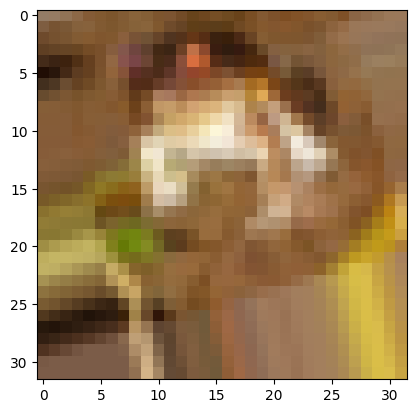

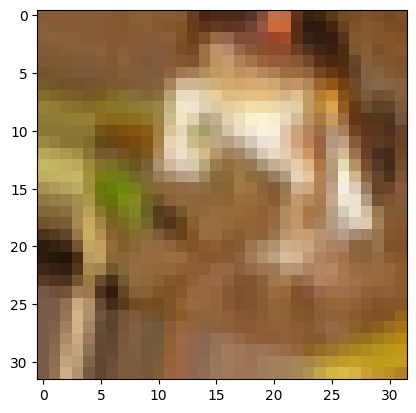

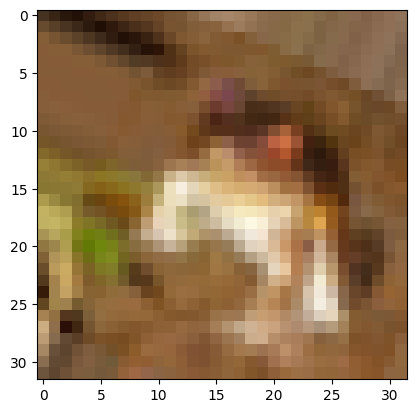

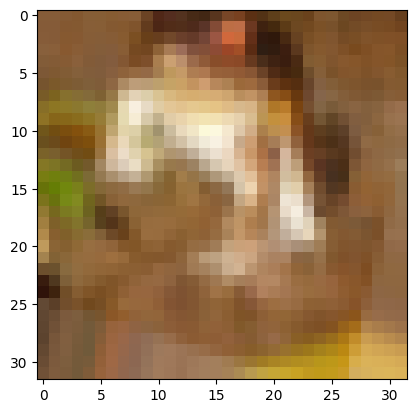

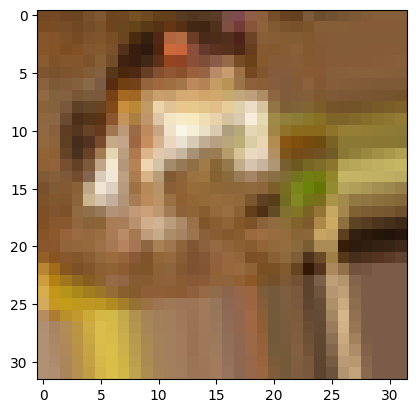

In [66]:
'''
Imports the image module from Keras, which contains utility functions for image loading, saving, and processing.
'''

from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator #perfoms data augmentation

# creates a data generator object that transforms images
datagen = ImageDataGenerator(
rotation_range=40, # images will be randomly rotated by a degree of 40
width_shift_range=0.2,# Images will be randomly shifted horizontally by up to 20% of their total width.
height_shift_range=0.2,#img randomly shifted vertically
shear_range=0.2,# Images will be randomly sheared (tilted along an axis) by up to 20 degrees.
zoom_range=0.2, #Images will be randomly zoomed in by up to 20%
horizontal_flip=True, # randomly flipped
fill_mode='nearest')
'''
When transformations cause pixels to go outside the image boundaries (e.g., rotation, shift),
this specifies how to fill the newly created empty pixels (here, it fills them with the nearest pixel value).
'''

# pick an image to transform
test_img = train_images[0]
'''
Converts the image (test_img), which is likely a NumPy array already,
into a standard Keras image array format if necessary. This step ensures consistency.
'''
img = image.img_to_array(test_img)  # convert image to numpy arry

'''
This is a crucial step. Keras's ImageDataGenerator (and many Keras/TensorFlow layers) expects input images in batches. Even if you're processing a single image, it needs to be wrapped in a batch dimension.
So, an image of shape (height, width, channels) is reshaped to (1, height, width, channels),
where 1 indicates a batch size of one.
img.shape represent height,width and channels of an image
'''
img = img.reshape((1,) + img.shape)  # reshape image

i = 0

for batch in datagen.flow(img, save_prefix='test', save_format='jpeg'):  # this loops runs forever until we break, saving images to current directory with specified prefix
    plt.figure(i)
    plot = plt.imshow(image.img_to_array(batch[0]))
    i += 1
    if i > 4:  # show 4 images
        break

plt.show()